# EDA Demo Showcase

This notebook keeps only the five presentation figures, each rendered as its own standalone chart with a consistent visual style.


In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
DATA_PATH = ROOT / "archive" / "artifacts" / "model_dataset_full.parquet"
EXPORT_DIR = ROOT / "outputs" / "eda_demo"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

THEME = {
    "primary": "#BFA7A0",
    "primary_dark": "#8F5B52",
    "accent": "#C65A46",
    "accent_dark": "#B30D0D",
    "olive": "#8C7A64",
    "gold": "#C9A46A",
    "rose": "#A45A52",
    "grid": "#E8DFDB",
    "text": "#1F1A17",
    "muted": "#6E625B",
    "bg": "#FFFFFF",
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": THEME["bg"],
    "axes.facecolor": THEME["bg"],
    "savefig.facecolor": THEME["bg"],
    "axes.edgecolor": "#D9CDC7",
    "axes.labelcolor": THEME["text"],
    "text.color": THEME["text"],
    "xtick.color": THEME["muted"],
    "ytick.color": THEME["muted"],
    "grid.color": THEME["grid"],
    "grid.linewidth": 0.9,
    "axes.titleweight": "bold",
    "axes.titlesize": 24,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "font.family": "DejaVu Sans",
})

MODEL_COLS = [
    "user_id",
    "product_id",
    "label",
    "u_total_orders",
    "u_avg_basket_size",
    "up_buy_cnt",
    "up_orders_since_last",
]

df = pd.read_parquet(DATA_PATH, columns=MODEL_COLS)
user_df = df[["user_id", "u_total_orders", "u_avg_basket_size"]].drop_duplicates("user_id").reset_index(drop=True)
pair_df = df[["product_id", "label", "up_buy_cnt", "up_orders_since_last"]].copy()

def finish_axis(ax):
    sns.despine(ax=ax)
    ax.grid(axis="y", alpha=0.9)
    ax.set_axisbelow(True)

print(f"Loaded {len(df):,} candidate rows")
print(f"Unique users: {user_df['user_id'].nunique():,}")
print(f"Unique user-product pairs: {len(pair_df):,}")


Loaded 8,474,661 candidate rows
Unique users: 131,209
Unique user-product pairs: 8,474,661


## 1. Class Distribution


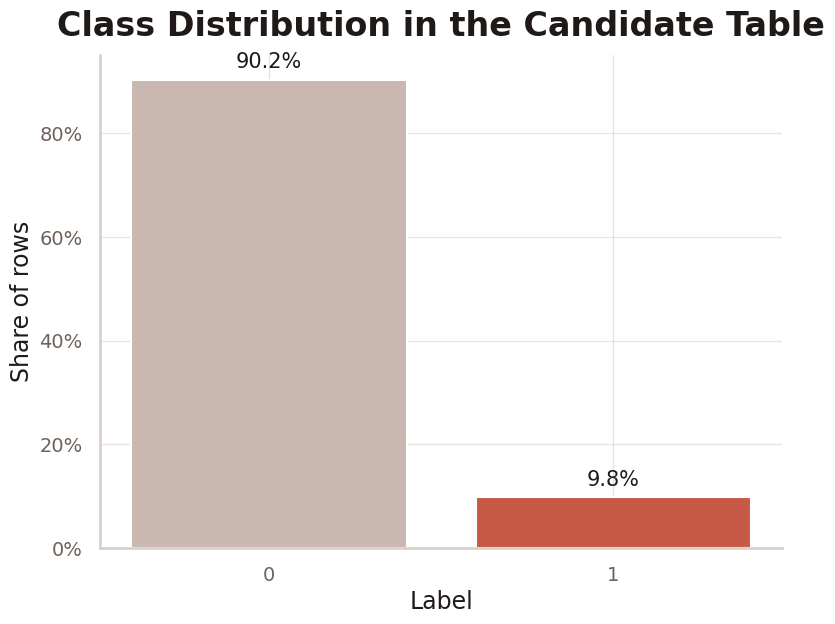

In [2]:
label_summary = (
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("class_label")
    .reset_index(name="n_rows")
)
label_summary["class_label"] = label_summary["class_label"].astype(str)
label_summary["share"] = label_summary["n_rows"] / label_summary["n_rows"].sum()

fig, ax = plt.subplots(figsize=(8.8, 6.4))
bars = ax.bar(
    label_summary["class_label"],
    label_summary["share"],
    color=["#C9B7B0", THEME["accent"]],
    width=0.8,
)
ax.set_title("Class Distribution in the Candidate Table", pad=14)
ax.set_xlabel("Label")
ax.set_ylabel("Share of rows")
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
for bar, value in zip(bars, label_summary["share"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=15,
    )
finish_axis(ax)
fig.savefig(EXPORT_DIR / "01_class_distribution.png", dpi=220, bbox_inches="tight")
plt.show()


## 2. User Order Frequency


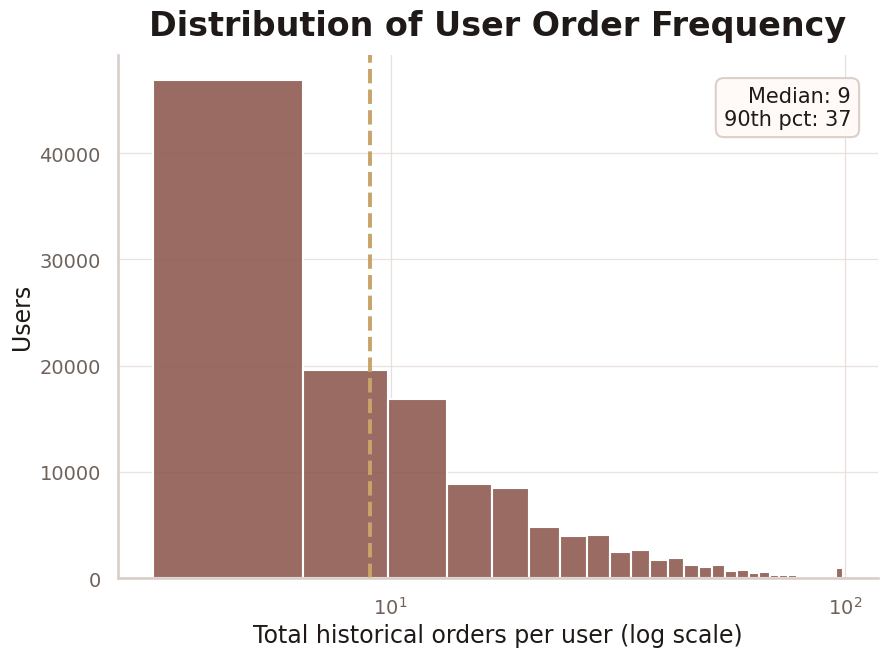

In [3]:
order_median = user_df["u_total_orders"].median()
order_p90 = user_df["u_total_orders"].quantile(0.9)

fig, ax = plt.subplots(figsize=(9.8, 6.8))
sns.histplot(
    user_df["u_total_orders"],
    bins=28,
    color=THEME["primary_dark"],
    alpha=0.9,
    edgecolor=THEME["bg"],
    ax=ax,
)
ax.axvline(order_median, color=THEME["gold"], lw=2.8, ls="--")
ax.set_xscale("log")
ax.set_title("Distribution of User Order Frequency", pad=14)
ax.set_xlabel("Total historical orders per user (log scale)")
ax.set_ylabel("Users")
ax.text(
    0.965,
    0.94,
    f"Median: {order_median:.0f}\n90th pct: {order_p90:.0f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=15,
    bbox=dict(boxstyle="round,pad=0.38", facecolor="#FFF9F7", edgecolor="#D9CDC7", alpha=0.95),
)
finish_axis(ax)
fig.savefig(EXPORT_DIR / "02_user_order_frequency.png", dpi=220, bbox_inches="tight")
plt.show()


## 3. Basket Size Distribution


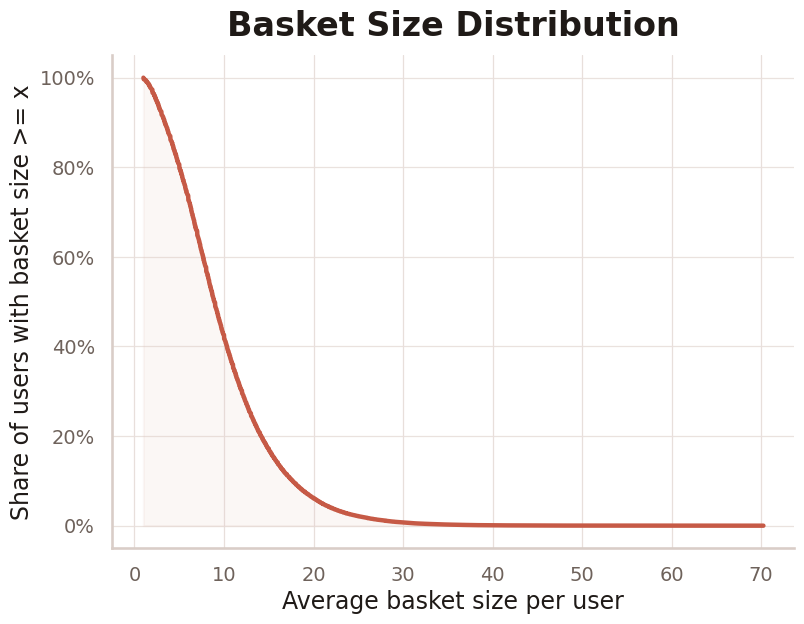

In [4]:
basket_ccdf = (
    user_df["u_avg_basket_size"]
    .value_counts()
    .sort_index()
    .rename_axis("avg_basket_size")
    .reset_index(name="n_users")
)
basket_ccdf["share_users"] = basket_ccdf["n_users"] / basket_ccdf["n_users"].sum()
basket_ccdf["ccdf"] = basket_ccdf["share_users"][::-1].cumsum()[::-1]

fig, ax = plt.subplots(figsize=(8.8, 6.4))
ax.plot(
    basket_ccdf["avg_basket_size"],
    basket_ccdf["ccdf"],
    color=THEME["accent"],
    lw=3.2,
)
ax.fill_between(
    basket_ccdf["avg_basket_size"],
    basket_ccdf["ccdf"],
    color="#E6C7BF",
    alpha=0.14,
)
ax.set_title("Basket Size Distribution", pad=14)
ax.set_xlabel("Average basket size per user")
ax.set_ylabel("Share of users with basket size >= x")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
finish_axis(ax)
fig.savefig(EXPORT_DIR / "03_basket_size_distribution.png", dpi=220, bbox_inches="tight")
plt.show()


## 4. Repeat-Count Bucket


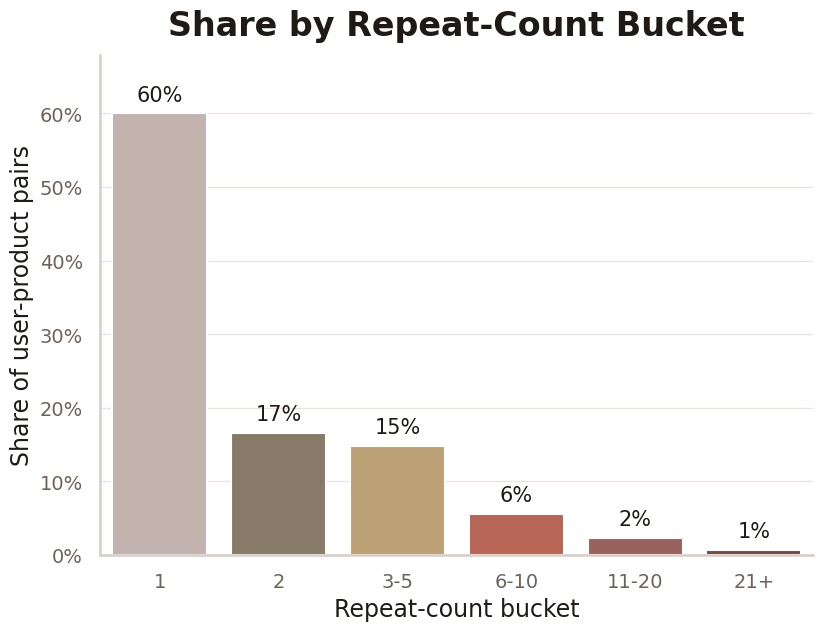

In [5]:
buy_count_summary = (
    pair_df["up_buy_cnt"]
    .value_counts()
    .sort_index()
    .rename_axis("up_buy_cnt")
    .reset_index(name="n_pairs")
)
buy_count_summary["bucket"] = pd.cut(
    buy_count_summary["up_buy_cnt"],
    bins=[0, 1, 2, 5, 10, 20, 100],
    labels=["1", "2", "3-5", "6-10", "11-20", "21+"],
)
bucket_view = buy_count_summary.groupby("bucket", observed=False)["n_pairs"].sum().reset_index()
bucket_view["share_pairs"] = bucket_view["n_pairs"] / bucket_view["n_pairs"].sum()

fig, ax = plt.subplots(figsize=(9.2, 6.5))
palette = [
    "#C7B1AA",
    THEME["olive"],
    THEME["gold"],
    THEME["accent"],
    THEME["rose"],
    "#7B433B",
]
bars = sns.barplot(data=bucket_view, x="bucket", y="share_pairs", hue="bucket", palette=palette, dodge=False, legend=False, ax=ax)
ax.set_title("Share by Repeat-Count Bucket", pad=14)
ax.set_xlabel("Repeat-count bucket")
ax.set_ylabel("Share of user-product pairs")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(bucket_view["share_pairs"]) + 0.08)
for patch, value in zip(ax.patches, bucket_view["share_pairs"]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        value + 0.012,
        f"{value:.0%}",
        ha="center",
        va="bottom",
        fontsize=15,
    )
finish_axis(ax)
fig.savefig(EXPORT_DIR / "04_repeat_count_bucket.png", dpi=220, bbox_inches="tight")
plt.show()


## 5. Reorder Probability by Order Recency


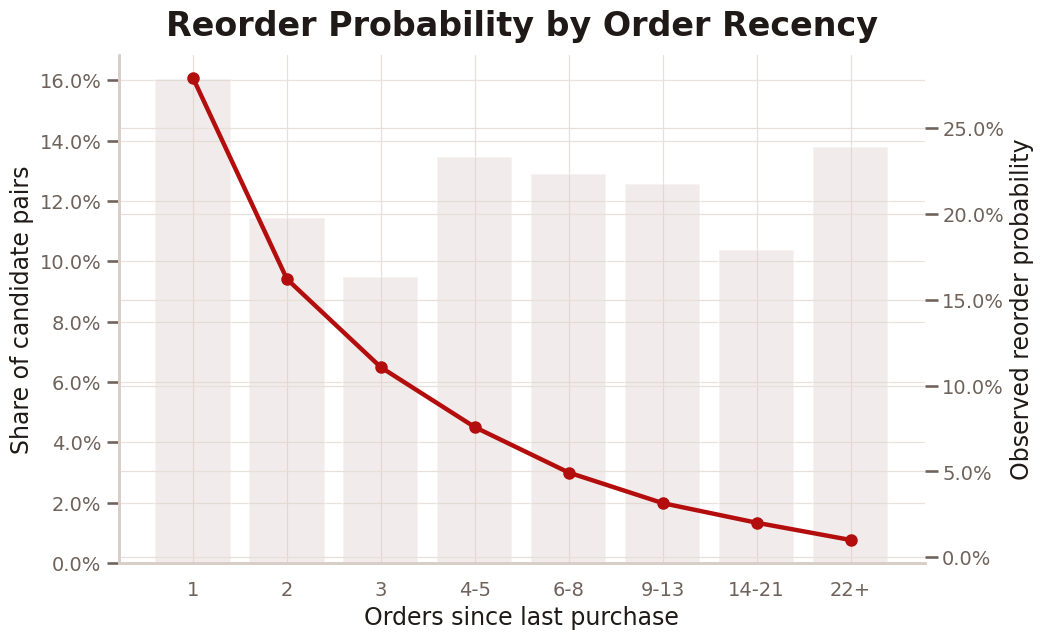

In [6]:
recency_orders = pair_df[["up_orders_since_last", "label"]].copy()
recency_orders["orders_bin"] = pd.cut(
    recency_orders["up_orders_since_last"],
    bins=[0, 1, 2, 3, 5, 8, 13, 21, 100],
    labels=["1", "2", "3", "4-5", "6-8", "9-13", "14-21", "22+"],
    include_lowest=True,
)
recency_orders_view = (
    recency_orders.groupby("orders_bin", observed=False)
    .agg(reorder_prob=("label", "mean"), n_pairs=("label", "size"))
    .reset_index()
)
recency_orders_view["pair_share"] = recency_orders_view["n_pairs"] / recency_orders_view["n_pairs"].sum()

fig, ax = plt.subplots(figsize=(10.4, 6.6))
bars = ax.bar(
    recency_orders_view["orders_bin"].astype(str),
    recency_orders_view["pair_share"],
    color="#D8CBC6",
    alpha=0.35,
)
ax2 = ax.twinx()
ax2.plot(
    recency_orders_view["orders_bin"].astype(str),
    recency_orders_view["reorder_prob"],
    color=THEME["accent_dark"],
    lw=3.2,
    marker="o",
    ms=8,
)
ax.set_title("Reorder Probability by Order Recency", pad=14)
ax.set_xlabel("Orders since last purchase")
ax.set_ylabel("Share of candidate pairs")
ax2.set_ylabel("Observed reorder probability")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
finish_axis(ax)
sns.despine(ax=ax2, left=False)
fig.savefig(EXPORT_DIR / "05_order_recency_reorder_probability.png", dpi=220, bbox_inches="tight")
plt.show()


## Exported Figures

Running the notebook saves the five presentation-ready figures to `outputs/eda_demo/`.
